# Phase 6 — Faust Vp: Resistivity-to-Velocity Modelling

**Field**: Dvalin, Norwegian Sea

The **Faust (1953) equation** estimates compressional velocity from formation resistivity and depth, providing synthetic Vp in intervals where the acoustic log is absent, unreliable, or has not been acquired.

**When Faust is applied:**
- Wells drilled without a sonic tool (common in older vintage wells)
- Shallow sections above the sonic logging start depth
- Intervals with severe cycle skipping that cannot be repaired
- As an independent check on measured Vp in shale-dominated intervals

**The Faust equation:**
$$V_p \; [\text{m/s}] = C \times (Z_{\text{TVD}} \; [\text{ft}] \times R_t \; [\Omega \cdot \text{m}])^{1/6}$$

Both depth $Z$ and resistivity $R_t$ act as proxies for **compaction state** — deeper, more resistive formations tend to be faster. The empirical constant $C$ must be calibrated well-by-well against intervals where Vp is measured.

**Limitations:** Faust works best in monotonic, shale-dominated compaction sequences. It deteriorates where:
- HC saturation elevates $R_t$ without increasing $V_p$ (gas sands)
- Lithology heterogeneity breaks the single $C$ assumption
- Cementation creates high $V_p$ without high $R_t$ (tight carbonates)

**Pipeline position**: Faust runs **before** density editing and elastic QC so that `VP_COMPOSITE` (measured Vp + Faust infill) is available to drive the Gardner relation in Phase 7 and the Castagna VS fill in Phase 8.

In [1]:
import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.transforms import blended_transform_factory
from scipy import stats
from pathlib import Path
import importlib, sys; sys.path.insert(0, '..')
import well_config; importlib.reload(well_config)
from well_config import get_cfg, form_colours, set_plot_style, load_tops, ACTIVE_WELL

# ── Well selection ────────────────────────────────────────────────────────────
WELL_NAME = ACTIVE_WELL   # ← change ACTIVE_WELL in well_config.py to switch all notebooks at once
#WELL_NAME = "15_9-F-1A"  # ← uncomment to override for this notebook only
cfg       = get_cfg(WELL_NAME)
set_plot_style()

# ── Paths ─────────────────────────────────────────────────────────────────────
WELL_FILE    = Path('..') / cfg['las_file']
TOPS_FILE    = Path('..') / cfg['tops_file']
COMPUTED_IN  = Path(f'../wells/{WELL_NAME}_computed.parquet')
FLAGS_IN     = Path(f'../wells/{WELL_NAME}_flags.parquet')
OUT_FILE     = Path(f'../wells/{WELL_NAME}_faust.parquet')

# ── Faust calibration domain (from config) ─────────────────────────────────────
RT_CALIB_MAX = cfg['faust_rt_max']   # Ω·m — exclude HC-elevated resistivity
RT_CALIB_MIN = cfg['faust_rt_min']   # Ω·m — exclude conductive artefacts

## Step 6.1 — Load Data

In [2]:
las = lasio.read(WELL_FILE)
df  = las.df()
df.replace(-999.25, np.nan, inplace=True)
df.rename(columns=cfg.get('curve_map', {}), inplace=True)
df.index.name = 'DEPTH_MD'

df = df.join(pd.read_parquet(COMPUTED_IN), how='left')
df = df.join(pd.read_parquet(FLAGS_IN),    how='left')

f1a = load_tops(TOPS_FILE, cfg['tops_well_id'])
TOPS_MD       = dict(zip(f1a['PICKS'], f1a['DEPTH'])) if not f1a.empty else {}
FORM_COLORS   = form_colours(TOPS_MD.keys())
RESERVOIR_TOP = f1a.iloc[-1]['PICKS'] if not f1a.empty else None

def nearest_idx(df, md):
    return df.index[np.argmin(np.abs(df.index.values - md))]

LOG_TOP  = cfg['log_top']  if cfg['log_top']  is not None else int(df.index[0])
LOG_BASE = cfg['log_base'] if cfg['log_base'] is not None else int(df.index[-1])
sub = df.loc[LOG_TOP:LOG_BASE].copy()

top_mds = sorted(TOPS_MD.items(), key=lambda x: x[1])
sub['FORMATION'] = 'Other'
for name, md_top in top_mds:
    sub.loc[sub.index >= md_top, 'FORMATION'] = name

# Vp from DT (Faust calibration only needs measured DT — no depth-shift required here)
sub['VP'] = 1e6 / sub['DT'] * 0.3048

# Depth in feet (Faust requires TVD in feet)
sub['Z_ft'] = sub['TVDSS_ABS'] * 3.28084

print(f"Interval: {LOG_TOP}–{LOG_BASE} m MD  ({len(sub):,} samples)")
print(f"VP valid  : {sub['VP'].notna().sum():,} samples")
print(f"RT range  : {sub['RT'].min():.2f} – {sub['RT'].max():.1f} Ω·m")
print(f"Z_ft range: {sub['Z_ft'].min():.0f} – {sub['Z_ft'].max():.0f} ft")

Interval: 0–4589 m MD  (30,112 samples)
VP valid  : 20,798 samples
RT range  : 0.42 – 518.6 Ω·m
Z_ft range: 1309 – 14173 ft


## Step 6.2 — Identify the Calibration Domain

The Faust constant $C$ is calibrated on intervals where:
1. **Measured Vp is available** (DT valid)
2. **$R_t$ is dominated by lithology/compaction**, not hydrocarbon saturation

Criterion (2) means excluding HC-elevated resistivity. We use $R_t < 10$ Ω·m as the threshold: above this, resistivity is more likely to reflect gas or oil saturation than rock properties.

Intervals with $R_t > 10$ Ω·m (HC-saturated reservoir) are excluded from calibration but will still receive a Faust Vp prediction — the Faust velocity will *underestimate* Vp in gas sands (gas raises $R_t$ but also lowers Vp), which is an expected and documentable artefact.

Vp available     : 20,798 samples
Calibration zone : 19,949 samples  (RT 0.2–10.0 Ω·m)
HC-elevated zone : 875 samples  (RT > 10.0 Ω·m — excluded from calibration)



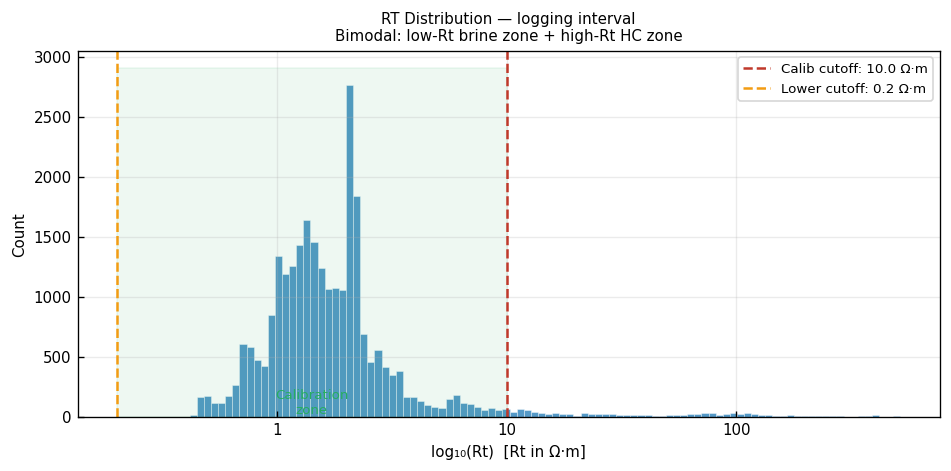

In [3]:
# ── Calibration mask ──────────────────────────────────────────────────────────
calib_mask = (
    sub['VP'].notna() &
    sub['RT'].notna() & (sub['RT'] > RT_CALIB_MIN) & (sub['RT'] < RT_CALIB_MAX) &
    sub['Z_ft'].notna() & (sub['Z_ft'] > 0)
)

n_total   = sub['VP'].notna().sum()
n_calib   = calib_mask.sum()
n_hc      = (sub['RT'] > RT_CALIB_MAX).sum()

print(f"Vp available     : {n_total:,} samples")
print(f"Calibration zone : {n_calib:,} samples  (RT {RT_CALIB_MIN}–{RT_CALIB_MAX} Ω·m)")
print(f"HC-elevated zone : {n_hc:,} samples  (RT > {RT_CALIB_MAX} Ω·m — excluded from calibration)")
print()

# RT distribution
rt_log = np.log10(sub['RT'].dropna())
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rt_log, bins=100, color='#2980B9', edgecolor='white', lw=0.3, alpha=0.8)
ax.axvline(np.log10(RT_CALIB_MAX), color='#C0392B', lw=1.5, ls='--',
           label=f'Calib cutoff: {RT_CALIB_MAX} Ω·m')
ax.axvline(np.log10(RT_CALIB_MIN), color='#F39C12', lw=1.5, ls='--',
           label=f'Lower cutoff: {RT_CALIB_MIN} Ω·m')
ax.set_xlabel('log₁₀(Rt)  [Rt in Ω·m]', fontsize=9)
ax.set_ylabel('Count', fontsize=9)
ax.set_title('RT Distribution — logging interval\n'
             'Bimodal: low-Rt brine zone + high-Rt HC zone', fontsize=9)
# Custom x tick labels
ticks = [-1, 0, 1, 2, 3, 4, 5]
ax.set_xticks(ticks)
ax.set_xticklabels([f'0.1' if t==-1 else f'{10**t:.0f}' for t in ticks])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 2000],
                  np.log10(RT_CALIB_MIN), np.log10(RT_CALIB_MAX),
                  alpha=0.08, color='#27AE60')
ax.text((np.log10(RT_CALIB_MIN)+np.log10(RT_CALIB_MAX))/2, 0,
        'Calibration\nzone', ha='center', va='bottom', fontsize=8, color='#27AE60')
plt.tight_layout()
plt.show()

## Step 6.3 — Global Calibration: Solve for Constant C

With the calibration mask defined, we solve for $C$ by rearranging the Faust equation:

$$C = \frac{V_p^{\text{meas}}}{(Z_{\text{TVD}} \cdot R_t)^{1/6}}$$

We use the **geometric mean** of the per-sample $C$ values (equivalent to a log-space arithmetic mean) as the best single-C estimate. The geometric mean is more robust than the arithmetic mean for log-normally distributed quantities like velocity and resistivity.

We also test whether the Faust exponent of 1/6 is appropriate for this dataset by running a free-exponent log-space regression.

In [4]:
vp_c   = sub.loc[calib_mask, 'VP'].values
z_ft_c = sub.loc[calib_mask, 'Z_ft'].values
rt_c   = sub.loc[calib_mask, 'RT'].values

# ── Geometric mean C (forced 1/6 exponent) ────────────────────────────────────
faust_arg_c = (z_ft_c * rt_c) ** (1/6)
C_per_sample = vp_c / faust_arg_c
C_global = float(np.exp(np.mean(np.log(C_per_sample))))

vp_faust_calib = C_global * faust_arg_c
rms_global = float(np.sqrt(np.mean((vp_c - vp_faust_calib)**2)))
r2_global  = float(1 - np.sum((vp_c - vp_faust_calib)**2) / np.sum((vp_c - vp_c.mean())**2))

# ── Free-exponent log-space regression ───────────────────────────────────────
log_vp   = np.log(vp_c)
log_prod = np.log(z_ft_c * rt_c)
slope, intercept, r, _, _ = stats.linregress(log_prod, log_vp)
C_free = float(np.exp(intercept))
exp_free = float(slope)

vp_faust_free = C_free * (z_ft_c * rt_c) ** exp_free
rms_free = float(np.sqrt(np.mean((vp_c - vp_faust_free)**2)))
r2_free  = float(r**2)

print("Faust calibration results:")
print(f"  Calibration samples : {n_calib:,}")
print()
print(f"  Fixed exponent (1/6 = 0.1667):")
print(f"    C_global       : {C_global:.1f}")
print(f"    RMS error      : {rms_global:.0f} m/s")
print(f"    R²             : {r2_global:.3f}")
print()
print(f"  Free-exponent regression:")
print(f"    C_free         : {C_free:.1f}")
print(f"    Exponent       : {exp_free:.4f}  (Faust = 0.1667)")
print(f"    RMS error      : {rms_free:.0f} m/s")
print(f"    R²             : {r2_free:.3f}")
print()
print("Interpretation:")
print(f"  The best-fit exponent ({exp_free:.3f}) departs from the Faust 1/6 assumption.")
print(f"  This is typical for lithologically heterogeneous sections where depth")
print(f"  and Rt are not the only drivers of velocity variation.")
print(f"  Faust remains useful as a 1st-order Vp estimate in data-sparse intervals.")
print(f"\n  Mean Vp in calibration zone: {vp_c.mean():.0f} m/s")
print(f"  RMS as % of mean Vp:         {100*rms_global/vp_c.mean():.1f}%")

Faust calibration results:
  Calibration samples : 19,949

  Fixed exponent (1/6 = 0.1667):
    C_global       : 564.9
    RMS error      : 218 m/s
    R²             : 0.842

  Free-exponent regression:
    C_free         : 285.9
    Exponent       : 0.2387  (Faust = 0.1667)
    RMS error      : 164 m/s
    R²             : 0.922

Interpretation:
  The best-fit exponent (0.239) departs from the Faust 1/6 assumption.
  This is typical for lithologically heterogeneous sections where depth
  and Rt are not the only drivers of velocity variation.
  Faust remains useful as a 1st-order Vp estimate in data-sparse intervals.

  Mean Vp in calibration zone: 2785 m/s
  RMS as % of mean Vp:         7.8%


## Step 6.4 — Per-Formation Calibration

Faust accuracy improves when each formation is calibrated independently with its own constant. This accounts for changes in lithology, fluid type, and cementation style between stratigraphic units.

In [5]:
form_constants = {}  # {formation_name: C_value}

print("Per-formation Faust calibration:")
print(f"{'Formation':<20} {'n_calib':>8} {'C':>8} {'RMS (m/s)':>10} {'R²':>7} {'Notes'}")
print("─" * 80)

top_list = sorted(TOPS_MD.items(), key=lambda x: x[1])
for i, (name, md_top) in enumerate(top_list):
    md_base = top_list[i+1][1] if i+1 < len(top_list) else LOG_BASE
    fm = sub.loc[md_top:md_base]

    fmask = (
        fm['VP'].notna() &
        fm['RT'].notna() & (fm['RT'] > RT_CALIB_MIN) & (fm['RT'] < RT_CALIB_MAX) &
        fm['Z_ft'].notna() & (fm['Z_ft'] > 0)
    )

    if fmask.sum() < 30:
        form_constants[name] = C_global
        print(f"{name:<20} {fmask.sum():>8} {'—':>8} {'—':>10} {'—':>7} "
              f"< 30 pts, using global C={C_global:.0f}")
        continue

    vp_f   = fm.loc[fmask, 'VP'].values
    z_f    = fm.loc[fmask, 'Z_ft'].values
    rt_f   = fm.loc[fmask, 'RT'].values
    fa_f   = (z_f * rt_f) ** (1/6)
    C_f    = float(np.exp(np.mean(np.log(vp_f / fa_f))))

    vp_pred_f = C_f * fa_f
    rms_f = float(np.sqrt(np.mean((vp_f - vp_pred_f)**2)))
    r2_f  = float(1 - np.sum((vp_f - vp_pred_f)**2) / np.sum((vp_f - vp_f.mean())**2))

    form_constants[name] = C_f

    quality = 'good' if r2_f > 0.3 else ('fair' if r2_f > 0.1 else 'poor')
    print(f"{name:<20} {fmask.sum():>8,} {C_f:>8.1f} {rms_f:>10.0f} {r2_f:>7.3f}  [{quality}]")

Per-formation Faust calibration:
Formation             n_calib        C  RMS (m/s)      R² Notes
────────────────────────────────────────────────────────────────────────────────
NAUST FM                  941    539.4        125   0.533  [good]
KAI FM                  4,207    515.3        101   0.593  [good]
SPRINGAR FM             5,797    559.2        163   0.736  [good]
LANGE FM                5,357    593.9        116   0.737  [good]
SPEKK FM                2,579    587.2        173   0.488  [good]
GARN FM                    29        —          —       — < 30 pts, using global C=565
Not Fm                  1,039    633.5        217  -0.816  [poor]


In [6]:
# ── Apply per-formation constants to compute VP_FAUST across full interval ─────
faust_arg = np.full(len(sub), np.nan)
valid = (sub['Z_ft'].notna()) & (sub['RT'].notna()) & (sub['Z_ft'] > 0) & (sub['RT'] > 0)
faust_arg[valid.values] = (sub.loc[valid, 'Z_ft'].values * sub.loc[valid, 'RT'].values) ** (1/6)

vp_faust = np.full(len(sub), np.nan)
c_faust  = np.full(len(sub), np.nan)

top_list_sorted = sorted(TOPS_MD.items(), key=lambda x: x[1])
for i, (name, md_top) in enumerate(top_list_sorted):
    md_base = top_list_sorted[i+1][1] if i+1 < len(top_list_sorted) else LOG_BASE
    C = form_constants.get(name, C_global)
    mask = (sub.index >= md_top) & (sub.index < md_base)  # numpy bool array
    vp_faust[mask] = C * faust_arg[mask]
    c_faust[mask]  = C

# Samples above the first top — use global C
if top_list_sorted:
    above = sub.index < top_list_sorted[0][1]
    vp_faust[above] = C_global * faust_arg[above]
    c_faust[above]  = C_global

sub['VP_FAUST'] = vp_faust
sub['C_FAUST']  = c_faust

print(f"VP_FAUST computed : {sub['VP_FAUST'].notna().sum():,} samples")
print(f"VP_FAUST range    : {sub['VP_FAUST'].min():.0f}–{sub['VP_FAUST'].max():.0f} m/s")

VP_FAUST computed : 26,543 samples
VP_FAUST range    : 1855–7854 m/s


## Step 6.5 — Calibration Crossplot: Vp_measured vs Vp_Faust

A 1:1 crossplot between the measured and Faust-predicted Vp is the primary calibration quality check. Systematic bias (points consistently above or below 1:1) can be reduced by adjusting $C$. High scatter reflects the fundamental limitation of single-parameter (resistivity) velocity prediction.

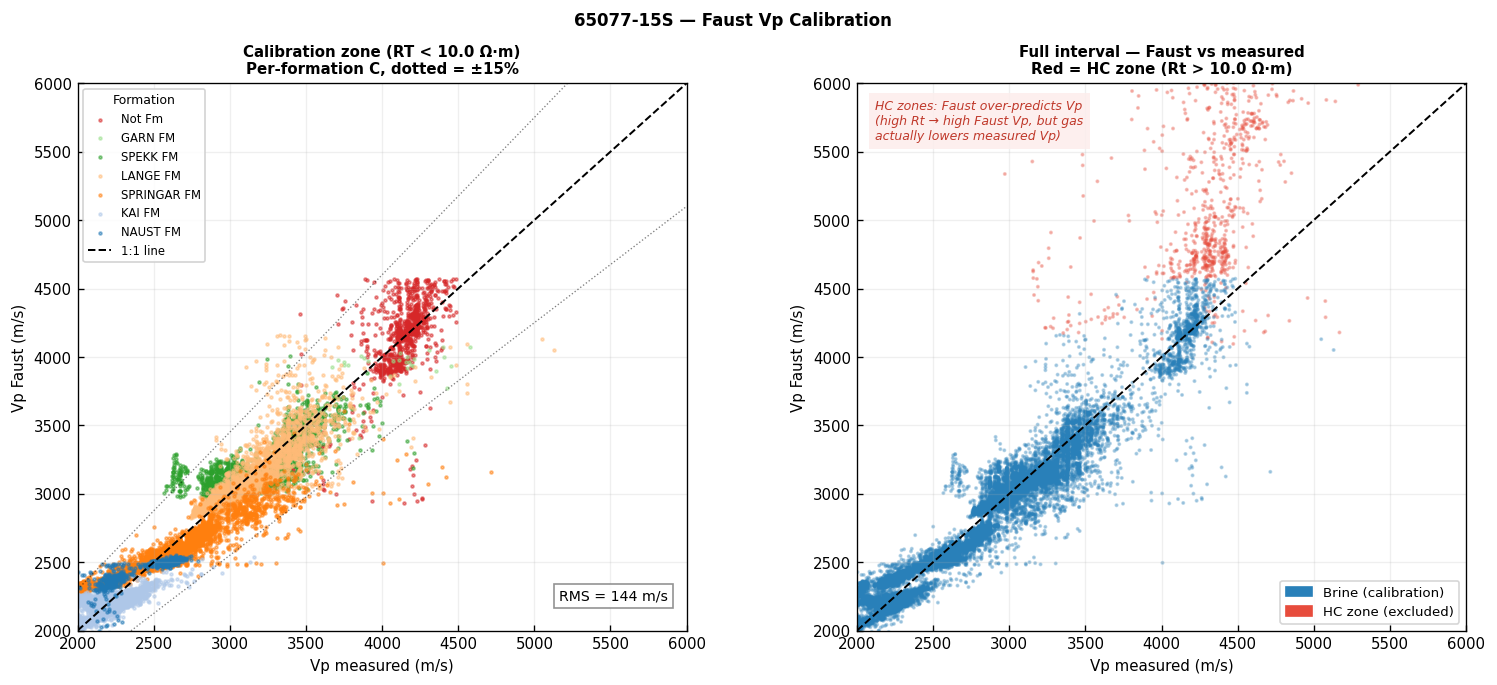

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.12, wspace=0.28)

# Left: calibration zone crossplot coloured by formation
ax = axes[0]
for form_name in list(TOPS_MD.keys())[::-1]:
    fm = sub[(sub['FORMATION'] == form_name) & calib_mask]
    if len(fm) == 0: continue
    ax.scatter(fm['VP'], fm['VP_FAUST'],
               s=3, alpha=0.5, rasterized=True,
               color=FORM_COLORS.get(form_name, '#888'), label=form_name)

lim = [2000, 6000]
ax.plot(lim, lim, 'k--', lw=1.2, label='1:1 line')
ax.plot(lim, [v*1.15 for v in lim], 'k:', lw=0.8, alpha=0.5)
ax.plot(lim, [v*0.85 for v in lim], 'k:', lw=0.8, alpha=0.5)
ax.set_xlim(*lim); ax.set_ylim(*lim)
ax.set_xlabel('Vp measured (m/s)', fontsize=9)
ax.set_ylabel('Vp Faust (m/s)', fontsize=9)
ax.set_title(f'Calibration zone (RT < {RT_CALIB_MAX} Ω·m)\n'
             f'Per-formation C, dotted = ±15%', fontsize=9, fontweight='bold')
ax.legend(fontsize=7, loc='upper left', framealpha=0.85,
          title='Formation', title_fontsize=7.5)
ax.grid(True, alpha=0.2)

# Add RMS annotation
calib_pts = sub[calib_mask & sub['VP_FAUST'].notna()]
rms_ann = np.sqrt(np.mean((calib_pts['VP'] - calib_pts['VP_FAUST'])**2))
ax.text(0.97, 0.05, f'RMS = {rms_ann:.0f} m/s',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5,
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', pad=3))

# Right: full interval including HC zone (shows scatter breakdown)
ax = axes[1]
# Colour by RT (brine vs HC)
all_pts = sub[sub['VP'].notna() & sub['VP_FAUST'].notna()]
colors_rt = np.where(all_pts['RT'] > RT_CALIB_MAX, '#E74C3C', '#2980B9')
ax.scatter(all_pts['VP'], all_pts['VP_FAUST'],
           c=colors_rt, s=2, alpha=0.3, rasterized=True)
ax.plot(lim, lim, 'k--', lw=1.2)
ax.set_xlim(*lim); ax.set_ylim(*lim)
ax.set_xlabel('Vp measured (m/s)', fontsize=9)
ax.set_ylabel('Vp Faust (m/s)', fontsize=9)
ax.set_title('Full interval — Faust vs measured\n'
             f'Red = HC zone (Rt > {RT_CALIB_MAX} Ω·m)', fontsize=9, fontweight='bold')
brine_patch = mpatches.Patch(color='#2980B9', label='Brine (calibration)')
hc_patch    = mpatches.Patch(color='#E74C3C', label='HC zone (excluded)')
ax.legend(handles=[brine_patch, hc_patch], fontsize=8)
ax.grid(True, alpha=0.2)
ax.text(0.03, 0.97,
        'HC zones: Faust over-predicts Vp\n'
        '(high Rt → high Faust Vp, but gas\n'
        'actually lowers measured Vp)',
        transform=ax.transAxes, ha='left', va='top', fontsize=7.5,
        color='#C0392B', style='italic',
        bbox=dict(facecolor='#FDEDEC', alpha=0.85, edgecolor='none', pad=4))

fig.suptitle(f'{WELL_NAME} — Faust Vp Calibration', fontsize=10, fontweight='bold')
plt.show()

## Step 6.5b — Per-Formation Fit Diagnostics

Residual = Vp_Faust − Vp_measured (positive = Faust over-predicts).

- **Box plot**: spread and bias per formation — a box centred on zero with narrow whiskers is ideal
- **R² bar**: how much Vp variance is explained by depth × Rt; R² < 0.5 (red line) means poor predictive power
- **RMS bar**: absolute error in m/s; 150 m/s ≈ 5% of mean Vp is shown as a rough acceptability threshold

Formation                  n      R²      RMS      MAE     Bias    RMS%
───────────────────────────────────────────────────────────────────────────
NAUST FM                 941   0.533      125      104       -6     5.1%
KAI FM                 4,207   0.593      101       79       -4     4.6%
SPRINGAR FM            5,797   0.736      163      121      -13     6.3%
LANGE FM               5,357   0.737      116       72       -1     3.8%
SPEKK FM               2,579   0.488      173      134       -5     5.4%
GARN FM                   29  -0.419      299      265     -168     7.3%  ⚑
Not Fm                 1,039  -0.816      217      142       +7     5.3%  ⚑

Bias: positive = Faust over-predicts Vp  |  ⚑ = |bias|>100 m/s or R²<0.3


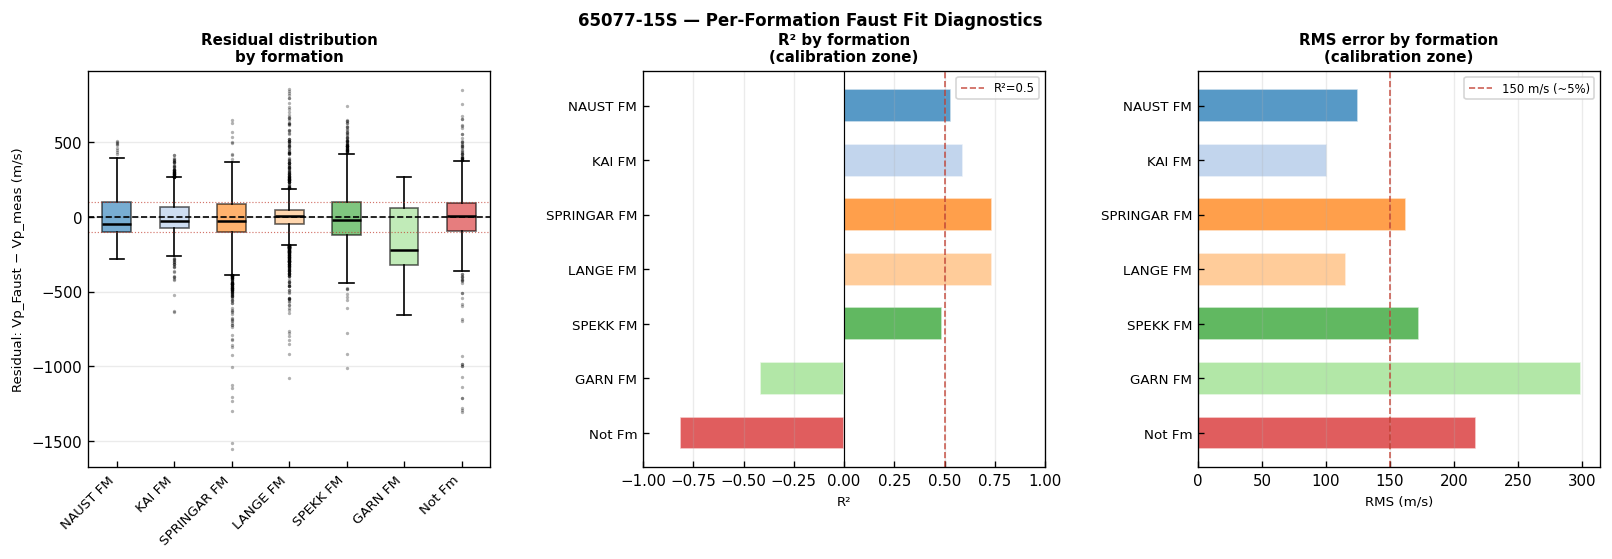

In [8]:
# ── Per-formation fit diagnostics ───────────────────────────────────────────
from matplotlib.lines import Line2D

form_diag = []
top_list_diag = sorted(TOPS_MD.items(), key=lambda x: x[1])

for i, (name, md_top) in enumerate(top_list_diag):
    md_base = top_list_diag[i+1][1] if i+1 < len(top_list_diag) else LOG_BASE
    fm = sub.loc[md_top:md_base]
    fmask = (
        fm['VP'].notna() &
        fm['VP_FAUST'].notna() &
        fm['RT'].notna() & (fm['RT'] > RT_CALIB_MIN) & (fm['RT'] < RT_CALIB_MAX) &
        fm['Z_ft'].notna() & (fm['Z_ft'] > 0)
    )
    n = int(fmask.sum())
    if n < 5:
        continue
    vp_m = fm.loc[fmask, 'VP'].values
    vp_f = fm.loc[fmask, 'VP_FAUST'].values
    resid = vp_f - vp_m
    rms  = float(np.sqrt(np.mean(resid**2)))
    mae  = float(np.mean(np.abs(resid)))
    bias = float(np.mean(resid))
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((vp_m - vp_m.mean())**2)
    r2   = float(1 - ss_res / ss_tot) if ss_tot > 0 else float('nan')
    rms_pct = 100 * rms / vp_m.mean()
    form_diag.append(dict(
        Formation=name, n=n, r2=r2, rms=rms, mae=mae,
        bias=bias, rms_pct=rms_pct, mean_vp=vp_m.mean(), residuals=resid
    ))

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'Formation':<20} {'n':>7} {'R²':>7} {'RMS':>8} {'MAE':>8} {'Bias':>8} {'RMS%':>7}")
print('─' * 75)
for row in form_diag:
    flag = '  ⚑' if abs(row['bias']) > 100 or row['r2'] < 0.3 else ''
    print(f"{row['Formation']:<20} {row['n']:>7,} {row['r2']:>7.3f} "
          f"{row['rms']:>8.0f} {row['mae']:>8.0f} {row['bias']:>+8.0f} {row['rms_pct']:>7.1f}%{flag}")
print()
print('Bias: positive = Faust over-predicts Vp  |  ⚑ = |bias|>100 m/s or R²<0.3')

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.subplots_adjust(left=0.07, right=0.97, top=0.88, bottom=0.22, wspace=0.38)

names  = [r['Formation'] for r in form_diag]
colors = [FORM_COLORS.get(n, '#888888') for n in names]
ypos   = np.arange(len(names))

# Left: residual box plot ─────────────────────────────────────────────────────
ax = axes[0]
bp = ax.boxplot(
    [r['residuals'] for r in form_diag],
    positions=ypos,
    widths=0.5,
    patch_artist=True,
    flierprops=dict(marker='.', ms=2, alpha=0.3),
    medianprops=dict(color='k', lw=1.5),
)
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col); patch.set_alpha(0.6)
ax.axhline(0,    color='k',       lw=1.0, ls='--')
ax.axhline( 100, color='#C0392B', lw=0.7, ls=':', alpha=0.7)
ax.axhline(-100, color='#C0392B', lw=0.7, ls=':', alpha=0.7)
ax.set_xticks(ypos)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Residual: Vp_Faust − Vp_meas (m/s)', fontsize=8)
ax.set_title('Residual distribution\nby formation', fontsize=9, fontweight='bold')
ax.grid(True, axis='y', alpha=0.25)

# Middle: R² bar chart ────────────────────────────────────────────────────────
ax = axes[1]
r2_vals = [r['r2'] for r in form_diag]
ax.barh(ypos, r2_vals, color=colors, alpha=0.75, edgecolor='white', height=0.6)
ax.axvline(0.5, color='#C0392B', lw=1.0, ls='--', alpha=0.8, label='R²=0.5')
ax.axvline(0,   color='k',       lw=0.7)
ax.set_yticks(ypos); ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel('R²', fontsize=8)
ax.set_xlim(-1.0, 1.0)
ax.set_title('R² by formation\n(calibration zone)', fontsize=9, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(True, axis='x', alpha=0.25)
ax.invert_yaxis()

# Right: RMS bar chart ────────────────────────────────────────────────────────
ax = axes[2]
rms_vals = [r['rms'] for r in form_diag]
ax.barh(ypos, rms_vals, color=colors, alpha=0.75, edgecolor='white', height=0.6)
ax.axvline(150, color='#C0392B', lw=1.0, ls='--', alpha=0.8, label='150 m/s (~5%)')
ax.set_yticks(ypos); ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel('RMS (m/s)', fontsize=8)
ax.set_title('RMS error by formation\n(calibration zone)', fontsize=9, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(True, axis='x', alpha=0.25)
ax.invert_yaxis()

fig.suptitle(f'{WELL_NAME} — Per-Formation Faust Fit Diagnostics',
             fontsize=10, fontweight='bold')
plt.show()


## Step 6.6 — VP_FAUST vs VP_MEAS: Log Display

Plotting both curves on the same log display shows where Faust prediction tracks the measured velocity and where it diverges. The HC interval is the expected zone of failure — Faust will over-predict Vp where gas raises Rt.

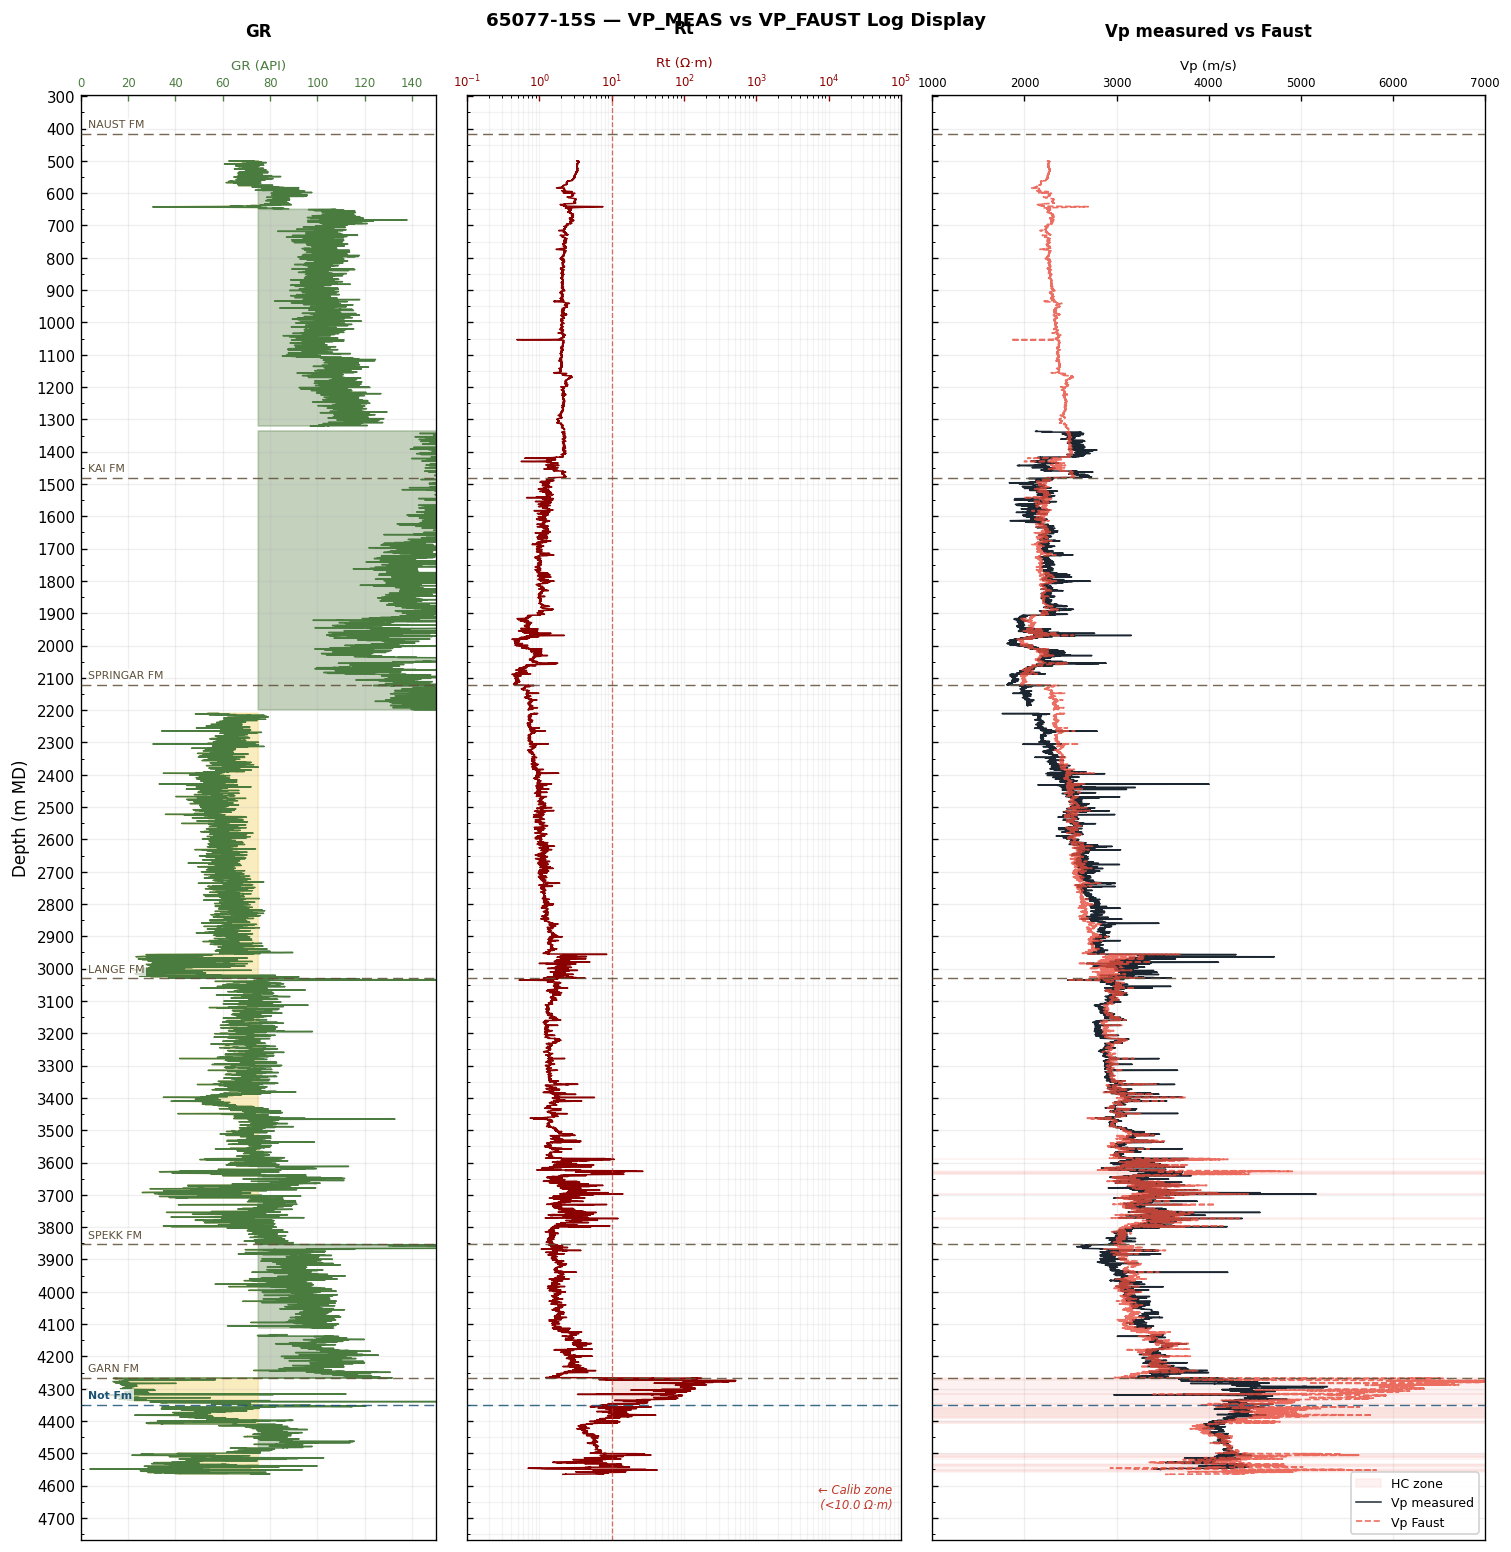

In [9]:
depth = sub.index.values

fig, axes = plt.subplots(1, 3, figsize=(13, 14), sharey=True,
                          gridspec_kw={'width_ratios': [0.9, 1.1, 1.4]})
fig.subplots_adjust(top=0.93, bottom=0.07, left=0.08, right=0.98, wspace=0.07)

# ── Track 1: GR ───────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(sub['GR'], depth, color='#4A7C40', lw=0.8)
ax.fill_betweenx(depth, sub['GR'], 75, where=sub['GR']>75, color='#6B8E5A', alpha=0.4)
ax.fill_betweenx(depth, sub['GR'], 75, where=sub['GR']<=75, color='#F0D060', alpha=0.4)
ax.set_xlim(0, 150); ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('GR (API)', color='#4A7C40', fontsize=8, labelpad=4)
ax.tick_params(axis='x', colors='#4A7C40', labelsize=7)
ax.set_ylabel('Depth (m MD)', fontsize=10)
ax.set_title('GR', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2); ax.invert_yaxis()
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))

# ── Track 2: RT (log scale) ────────────────────────────────────────────────────
ax = axes[1]
# Shade HC zone (RT > calibration max)
ax.fill_betweenx(depth, sub['RT'].clip(0.1, 1e5), RT_CALIB_MAX,
                  where=sub['RT'] > RT_CALIB_MAX,
                  color='#FADBD8', alpha=0.7)
ax.plot(sub['RT'].clip(0.1, 1e5), depth, color='#8B0000', lw=0.9)
ax.set_xscale('log')
ax.set_xlim(0.1, 1e5)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('Rt (Ω·m)', color='#8B0000', fontsize=8, labelpad=4)
ax.tick_params(axis='x', colors='#8B0000', labelsize=7)
ax.axvline(RT_CALIB_MAX, color='#C0392B', lw=0.8, ls='--', alpha=0.7)
ax.set_title('Rt', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, which='both', alpha=0.15)
ax.text(0.98, 0.02, f'← Calib zone\n   (<{RT_CALIB_MAX} Ω·m)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=7,
        color='#C0392B', style='italic')

# ── Track 3: VP_MEAS vs VP_FAUST ──────────────────────────────────────────────
ax = axes[2]

# Shade where HC zone (Faust known to overpredict)
hc_mask = sub['RT'] > RT_CALIB_MAX
ax.fill_betweenx(depth, 1000, 7000,
                  where=hc_mask, color='#FADBD8', alpha=0.35, label='HC zone')

ax.plot(sub['VP'],        depth, color='#1B2631', lw=0.9, label='Vp measured')
ax.plot(sub['VP_FAUST'],  depth, color='#E74C3C', lw=1.0, ls='--',
        alpha=0.8, label='Vp Faust')

ax.set_xlim(1000, 7000)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('Vp (m/s)', fontsize=8, labelpad=4)
ax.tick_params(axis='x', labelsize=7)
ax.legend(fontsize=7.5, loc='lower right', framealpha=0.85)
ax.set_title('Vp measured vs Faust', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2)

# ── Formation tops ─────────────────────────────────────────────────────────────
label_trans = blended_transform_factory(axes[0].transAxes, axes[0].transData)
for name, md_top in TOPS_MD.items():
    if not (depth.min() <= md_top <= depth.max()): continue
    is_res = (name == RESERVOIR_TOP)
    lc = '#1A5276' if is_res else '#5D4E37'
    for ax in axes:
        ax.axhline(md_top, color=lc, lw=0.85, ls=(0,(7,4)), alpha=0.85, zorder=4)
    axes[0].text(0.02, md_top-(depth[-1]-depth[0])*0.003, name,
                 transform=label_trans, fontsize=6.5, va='bottom',
                 color=is_res and '#1A5276' or '#5D4E37',
                 fontweight='bold' if is_res else 'normal',
                 bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.2), zorder=5)

fig.suptitle(f'{WELL_NAME} — VP_MEAS vs VP_FAUST Log Display',
             fontsize=11, fontweight='bold')
plt.show()

## Step 6.7 — Build VP_COMPOSITE: Measured Where Available, Faust Elsewhere

The composite Vp log uses:
- **Measured Vp** (from DT) where the acoustic log is valid and QC'd
- **Faust Vp** where DT is null (NaN gaps in the acoustic log)

VP_COMPOSITE is the production-ready Vp that Phase 7 (density editing) uses for Gardner predictions and Phase 8 (elastic QC) uses to fill VS_OK gaps via Castagna.

In [10]:
# VP_COMPOSITE: prefer measured, fall back to Faust
sub['VP_COMPOSITE'] = sub['VP'].copy()
sub['VP_SOURCE']    = 0   # 0 = measured, 1 = Faust

null_vp = sub['VP_COMPOSITE'].isna()
sub.loc[null_vp & sub['VP_FAUST'].notna(), 'VP_COMPOSITE'] = \
    sub.loc[null_vp & sub['VP_FAUST'].notna(), 'VP_FAUST']
sub.loc[null_vp & sub['VP_FAUST'].notna(), 'VP_SOURCE'] = 1

n_meas  = (sub['VP_SOURCE'] == 0).sum()
n_faust = (sub['VP_SOURCE'] == 1).sum()
n_nan   = sub['VP_COMPOSITE'].isna().sum()

print("VP_COMPOSITE summary:")
print(f"  From measured DT : {n_meas:,} samples ({100*n_meas/len(sub):.1f}%)")
print(f"  From Faust       : {n_faust:,} samples ({100*n_faust/len(sub):.1f}%)")
print(f"  Still NaN        : {n_nan:,} samples")
print()
print(f"VP_COMPOSITE range: {sub['VP_COMPOSITE'].min():.0f}–{sub['VP_COMPOSITE'].max():.0f} m/s")

# ── Save ──────────────────────────────────────────────────────────────────────
out_cols = ['VP_FAUST', 'VP_COMPOSITE', 'VP_SOURCE', 'C_FAUST']
out_full = sub[out_cols].reindex(df.index)
out_full.to_parquet(OUT_FILE)

print(f"\nSaved to : {OUT_FILE}")
print(f"Columns  : {out_cols}")

VP_COMPOSITE summary:
  From measured DT : 24,362 samples (80.9%)
  From Faust       : 5,750 samples (19.1%)
  Still NaN        : 3,564 samples

VP_COMPOSITE range: 1757–5821 m/s

Saved to : ../wells/65077-15S_faust.parquet
Columns  : ['VP_FAUST', 'VP_COMPOSITE', 'VP_SOURCE', 'C_FAUST']


## Step 6.7b — Faust Replacement Boundary Continuity

At every point where VP_COMPOSITE switches from measured to Faust (or back), the velocity
should connect smoothly. A large step at a boundary means the Faust calibration predicts
a velocity that is inconsistent with the adjacent measured log — a local under- or over-prediction.

- **Top boundary** (measured → Faust): step = Vp_Faust_first − Vp_meas_last
- **Base boundary** (Faust → measured): step = Vp_meas_first − Vp_Faust_last

Thresholds: |step| < 50 m/s = smooth (green), 50–100 m/s = marginal (orange), >100 m/s = flag (red).

Faust replacement boundary continuity — 5 transitions
 Depth (m)  Type  Vp_before  Vp_after  Step (m/s)  Step% Formation            Flag
───────────────────────────────────────────────────────────────────────────────────────────────
    2186.0   top        2030      2348        +317 +14.5%   SPRINGAR FM           ⚑
    2396.3   top        2255      2486        +230  +9.7%   SPRINGAR FM           ⚑
    2396.5  base        2486      2235        -251 -10.6%   SPRINGAR FM           ⚑
    4113.1   top        3330      3288         -42  -1.3%   SPEKK FM            
    4550.2   top        3481      4929       +1448 +34.4%   Not Fm                ⚑

4 of 5 boundaries have |step| > 100 m/s
Mean |step|: 458 m/s  |  Max |step|: 1448 m/s


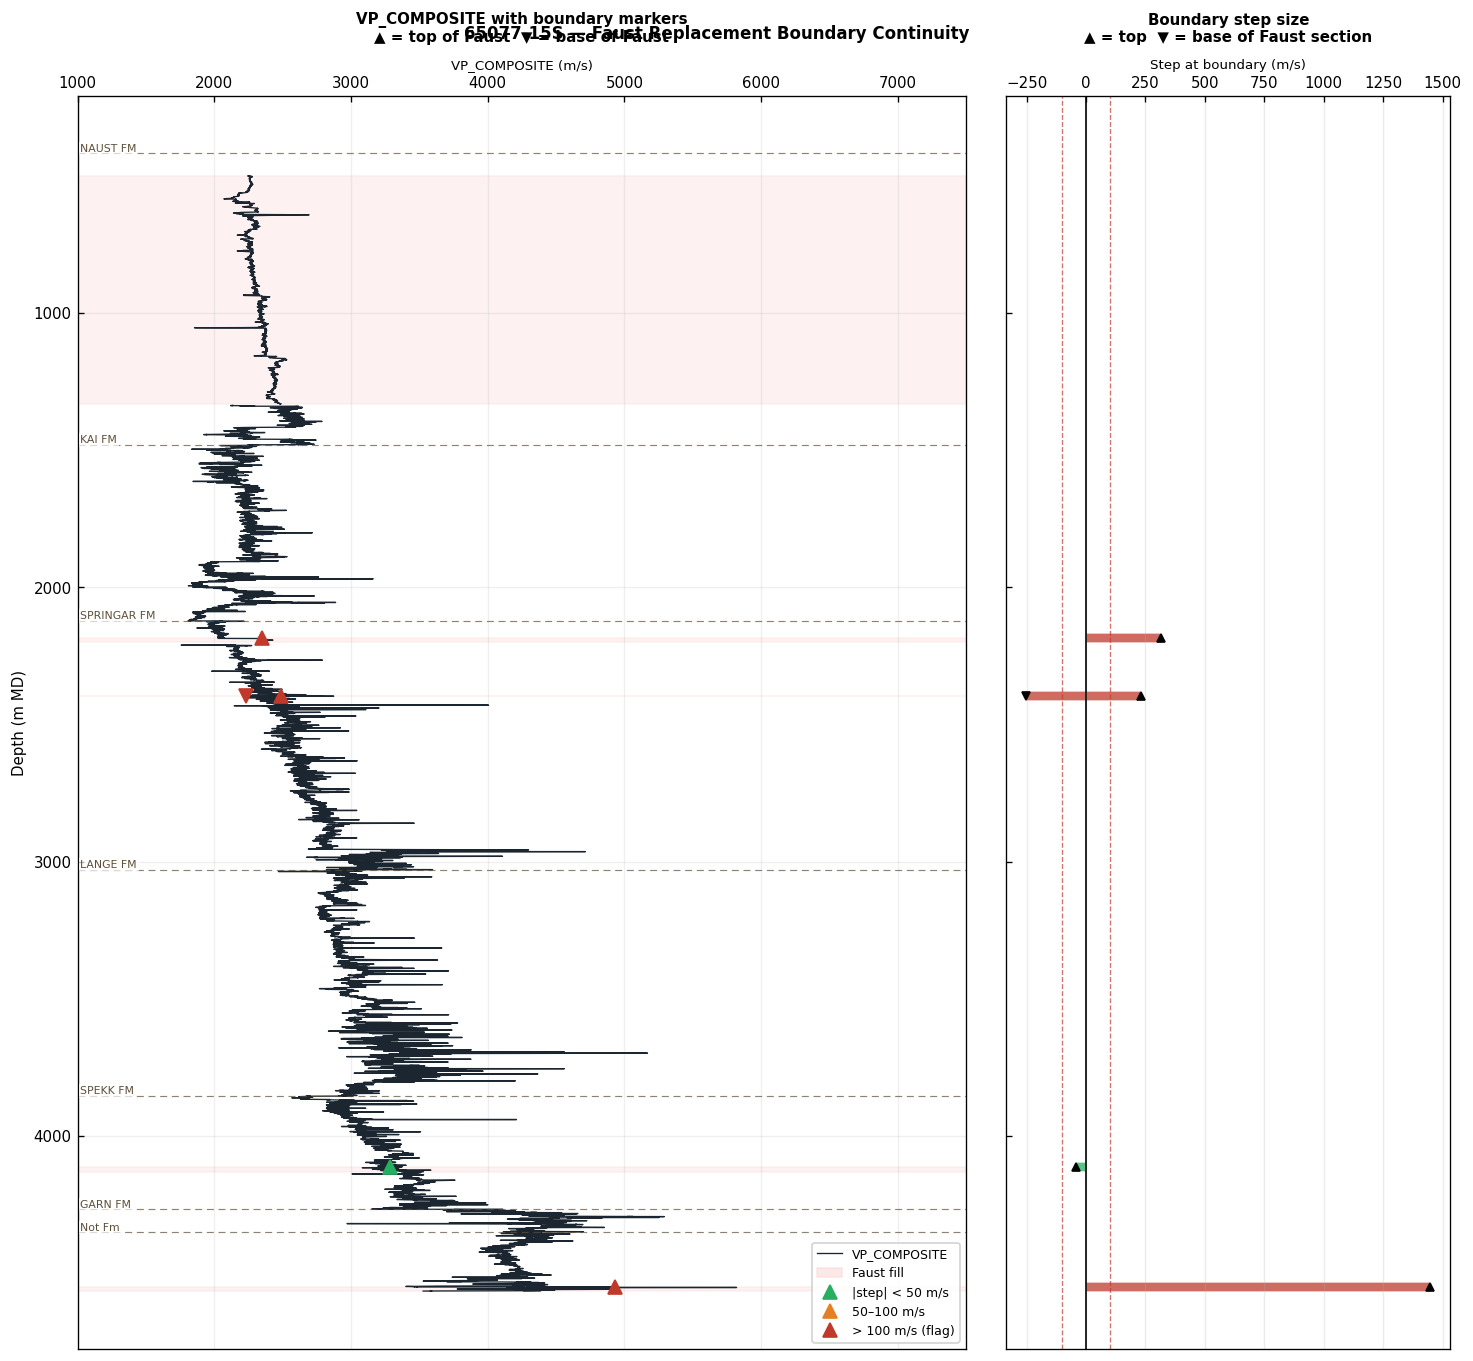

In [11]:
# ── Faust replacement boundary continuity ────────────────────────────────────
from matplotlib.lines import Line2D

src  = sub['VP_SOURCE'].copy()       # 0 = measured, 1 = Faust
comp = sub['VP_COMPOSITE'].copy()
delta = src.diff().fillna(0)         # +1 = 0→1 start, -1 = 1→0 end

boundaries = []
for idx_pos, d_val in delta.items():
    if d_val == 0:
        continue
    pos = sub.index.get_loc(idx_pos)
    if pos == 0:
        continue
    prev_idx  = sub.index[pos - 1]
    vp_before = comp.loc[prev_idx]
    vp_after  = comp.loc[idx_pos]
    if np.isnan(vp_before) or np.isnan(vp_after):
        continue
    step      = float(vp_after - vp_before)
    local_avg = (vp_before + vp_after) / 2
    step_pct  = 100 * step / local_avg
    btype     = 'top' if d_val > 0 else 'base'
    fm_name   = sub.loc[idx_pos, 'FORMATION']
    boundaries.append(dict(
        depth_m=idx_pos, type=btype,
        vp_before=float(vp_before), vp_after=float(vp_after),
        step_ms=step, step_pct=step_pct, formation=fm_name
    ))

bdf = (pd.DataFrame(boundaries)
         .sort_values('depth_m')
         .reset_index(drop=True))

# ── Print table ───────────────────────────────────────────────────────────────
print(f"Faust replacement boundary continuity — {len(bdf)} transitions")
print(f"{'Depth (m)':>10} {'Type':>5} {'Vp_before':>10} {'Vp_after':>9} "
      f"{'Step (m/s)':>11} {'Step%':>6} {'Formation':<20} Flag")
print('─' * 95)
for _, row in bdf.iterrows():
    flag = '  ⚑' if abs(row['step_ms']) > 100 else ''
    print(f"{row['depth_m']:>10.1f} {row['type']:>5}  {row['vp_before']:>10.0f} "
          f"{row['vp_after']:>9.0f} {row['step_ms']:>+11.0f} {row['step_pct']:>+5.1f}% "
          f"  {row['formation']:<20}{flag}")
n_large = int((bdf['step_ms'].abs() > 100).sum())
print(f"\n{n_large} of {len(bdf)} boundaries have |step| > 100 m/s")
print(f"Mean |step|: {bdf['step_ms'].abs().mean():.0f} m/s  |"
      f"  Max |step|: {bdf['step_ms'].abs().max():.0f} m/s")

# ── Figure ────────────────────────────────────────────────────────────────────
def _step_color(s):
    return '#C0392B' if abs(s) > 100 else '#E67E22' if abs(s) > 50 else '#27AE60'

fig, axes = plt.subplots(1, 2, figsize=(13, 12), sharey=True,
                          gridspec_kw={'width_ratios': [2, 1]})
fig.subplots_adjust(left=0.09, right=0.97, top=0.93, bottom=0.06, wspace=0.06)

depth_arr = sub.index.values

# Left: VP_COMPOSITE depth trace ──────────────────────────────────────────────
ax = axes[0]
faust_on = sub['VP_SOURCE'] == 1
ax.fill_betweenx(depth_arr, 1000, 7500,
                  where=faust_on.values, color='#FADBD8', alpha=0.35,
                  label='Faust fill')
ax.plot(sub['VP_COMPOSITE'], depth_arr, color='#1B2631', lw=0.8,
        label='VP_COMPOSITE')
for _, row in bdf.iterrows():
    col = _step_color(row['step_ms'])
    mk  = '^' if row['type'] == 'top' else 'v'
    ax.plot(row['vp_after'], row['depth_m'], marker=mk, color=col,
            ms=8, zorder=6, clip_on=False)
for name, md_top in TOPS_MD.items():
    if depth_arr.min() <= md_top <= depth_arr.max():
        ax.axhline(md_top, color='#5D4E37', lw=0.7, ls=(0,(6,4)), alpha=0.7)
        ax.text(1020, md_top, name, fontsize=6.5, va='bottom', color='#5D4E37',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
lh = [
    Line2D([0],[0], color='#1B2631', lw=0.8, label='VP_COMPOSITE'),
    mpatches.Patch(color='#FADBD8', alpha=0.6, label='Faust fill'),
    Line2D([0],[0], marker='^', color='#27AE60', ms=8, ls='none', label='|step| < 50 m/s'),
    Line2D([0],[0], marker='^', color='#E67E22', ms=8, ls='none', label='50–100 m/s'),
    Line2D([0],[0], marker='^', color='#C0392B', ms=8, ls='none', label='> 100 m/s (flag)'),
]
ax.legend(handles=lh, fontsize=7.5, loc='lower right', framealpha=0.85)
ax.set_xlim(1000, 7500)
ax.set_ylabel('Depth (m MD)', fontsize=9)
ax.set_xlabel('VP_COMPOSITE (m/s)', fontsize=8)
ax.set_title('VP_COMPOSITE with boundary markers\n▲ = top of Faust  ▼ = base of Faust',
             fontsize=9, fontweight='bold', pad=10)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.invert_yaxis()
ax.grid(True, alpha=0.2)

# Right: step-size bar chart ──────────────────────────────────────────────────
ax = axes[1]
depth_range = depth_arr[-1] - depth_arr[0]
bar_h = depth_range * 0.008
for _, row in bdf.iterrows():
    col = _step_color(row['step_ms'])
    mk  = '^' if row['type'] == 'top' else 'v'
    ax.barh(row['depth_m'], row['step_ms'], height=bar_h,
            color=col, alpha=0.75, edgecolor='white')
    ax.plot(row['step_ms'], row['depth_m'], marker=mk, color='k', ms=5, zorder=5)
ax.axvline(  0,   color='k',       lw=1.0)
ax.axvline( 100,  color='#C0392B', lw=0.8, ls='--', alpha=0.7)
ax.axvline(-100,  color='#C0392B', lw=0.8, ls='--', alpha=0.7)
ax.set_xlabel('Step at boundary (m/s)', fontsize=8)
ax.set_title('Boundary step size\n▲ = top  ▼ = base of Faust section',
             fontsize=9, fontweight='bold', pad=10)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.grid(True, axis='x', alpha=0.25)

fig.suptitle(f'{WELL_NAME} — Faust Replacement Boundary Continuity',
             fontsize=10, fontweight='bold')
plt.show()


---
## Phase 6 Summary

| Item | Value / Status |
|------|----------------|
| Faust exponent | 1/6 (standard) |
| Calibration domain | RT 0.2–10 Ω·m (brine-saturated intervals only) |
| Global C | Per-formation C used in VP_FAUST; see Step 6.4 output |
| Calibration RMS | See Step 6.3/6.4 output |
| HC zone behaviour | Faust **over-predicts** Vp in gas sand (high Rt → high Faust, but gas lowers Vp) |
| VP_COMPOSITE | Measured DT where valid; Faust fills NaN gaps |
| Output saved | `wells/{WELL_NAME}_faust.parquet` |

**Key takeaway on Faust limitations**: The Faust equation is a regional reconnaissance tool, not a precision predictor. In this lithologically heterogeneous Jurassic section, the best single-formation R² values (~0.3–0.5) are typical of its application. For a well without DT, Faust-based Vp would be preferable to no Vp at all, but the uncertainty (±15%) should be carried forward explicitly.

**Next**: Notebook `07_density_editing.ipynb` — Gardner density infill using VP_COMPOSITE (Phase 7).